## Task 1: Import the Libraries

In [2]:
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

## Task 2: Load the Dataset

In [27]:
data = pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv")

In [4]:
data.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Task 3: Explore the Dataset

In [5]:
data.iloc[:, :-1].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Task 4: Explore the Variables 

In [6]:
data.iloc[:, :-1].corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


## Task 5: Check for Null Values 

In [7]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
data = data.dropna()
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Task 6: Prepare the Data

In [9]:
data = pd.get_dummies(data)
data = data.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 8]]
data.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,False,True,False,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,False,True,False,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,False,True,False,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,False,True,False,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,False,True,False,342200.0


## Task 7: Create the Dependent Variable  

In [10]:
y = data.iloc[:, -1]
y.head() 

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

## Task 8: Create the Independent Variable 

In [11]:
X = data.iloc[:, :-1]
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,False,True,False


## Task 9: Split the Data with Scikit-learn

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=43)

## Task 10: Train and Fit the Model

In [13]:
X_train_new = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_new.astype('float') ).fit()

## Task 11: Run Summary and Interpret the Findings

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     2294.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:45:04   Log-Likelihood:            -1.9249e+05
No. Observations:               15324   AIC:                         3.850e+05
Df Residuals:                   15311   BIC:                         3.851e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -1.838e+06   8.57e+04    -21.452      0.000   -2.01e+06   -1.67e+06
longitude                  -2.636e+04   1187.346    -22.205      0.000   -2.87e+04    -2.4e+04
latitude                   -2.515e+04   1169.300    -21.511      0.000   -2.74e+04   -2.29e+04
housing_median_age          1052.8379     51.123     20.594      0.000     952.631    1153.045
total_rooms                   -6.5613      0.926     -7.083      0.000      -8.377      -4.746
total_bedrooms               100.8903      8.100     12.455      0.000      85.013     116.768
population                   -40.4693      1.314    -30.808      0.000     -43.044     -37.895
households                    55.2858      8.839      6.255      0.000      37.960      72.612
median_income               3.917e+04    395.022     99.170      0.000    3.84e+04    3.99e+04
ocean_proximity_<1H OCEAN  -3.868e+05   1.79e+04    -21.552      0.000   -4.22e+05   -3.52e+05
ocean_proximity_INLAND     -4.271e+05   1.68e+04    -25.350      0.000    -4.6e+05   -3.94e+05
ocean_proximity_ISLAND     -2.513e+05   3.39e+04     -7.412      0.000   -3.18e+05   -1.85e+05
ocean_proximity_NEAR BAY   -3.904e+05   1.85e+04    -21.133      0.000   -4.27e+05   -3.54e+05
ocean_proximity_NEAR OCEAN -3.828e+05   1.84e+04    -20.850      0.000   -4.19e+05   -3.47e+05
==============================================================================
Omnibus:                     3533.302   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11513.048
Skew:                           1.164   Prob(JB):                         0.00
Kurtosis:                       6.551   Cond. No.                     1.88e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.7e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

## Task 12 :  Plot the Findings

Text(0.5, 1.0, 'Linear correlation median_income / median house value')

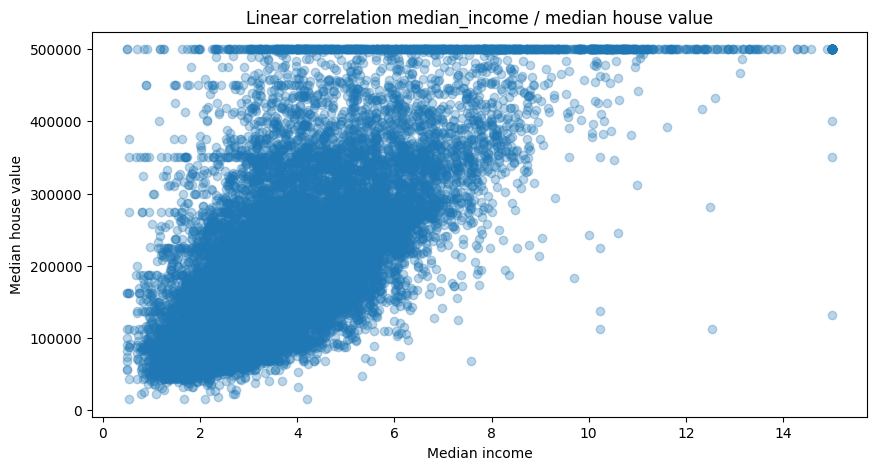

In [15]:
plt.figure(figsize=(10,5))
plt.scatter(data["median_income"], data["median_house_value"], alpha=0.3)
plt.xlabel('Median income')
plt.ylabel('Median house value')
plt.title('Linear correlation median_income / median house value')

In [16]:
X_test_new = sm.add_constant(X_test)
predictions = model.predict(X_test_new)

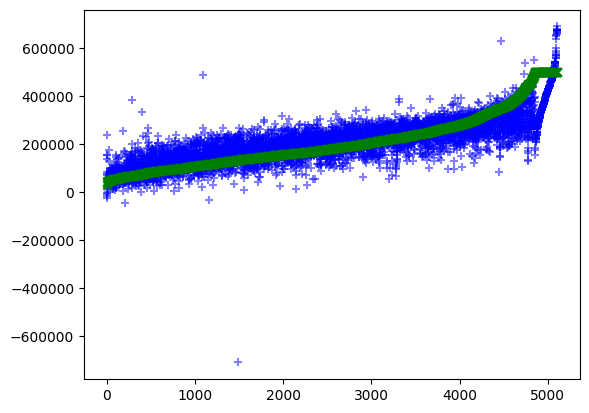

In [17]:
df = pd.DataFrame({"Y_test": y_test , "Y_pred" : predictions})
df.sort_values(by=['Y_test', 'Y_pred'], inplace=True, ignore_index=True)
df['idx'] = range(len(df))
plt.scatter(df.idx, df.Y_pred, c="blue", alpha=0.5, marker="+")
plt.scatter(df.idx, df.Y_test, c="green", alpha=0.4, marker="x")
plt.show()

In [18]:
mean_squared_error(y_test, predictions, multioutput='raw_values')

array([4.55087835e+09])

## Task 13 :  Distribution of House Prices

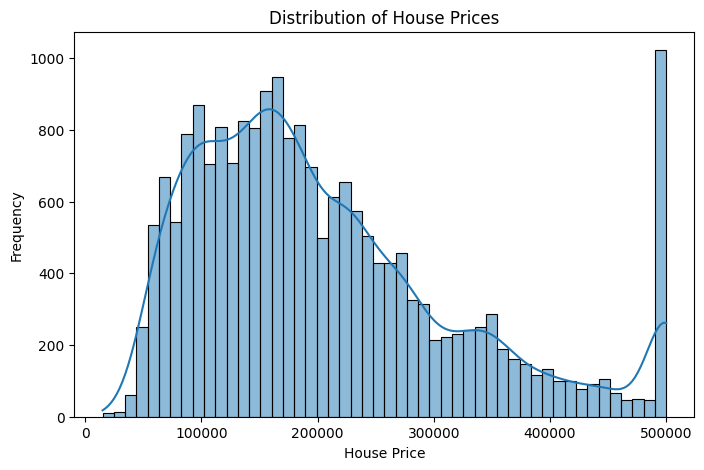

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data['median_house_value'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

## Task 14: Correlation Heatmap (Important Analysis)

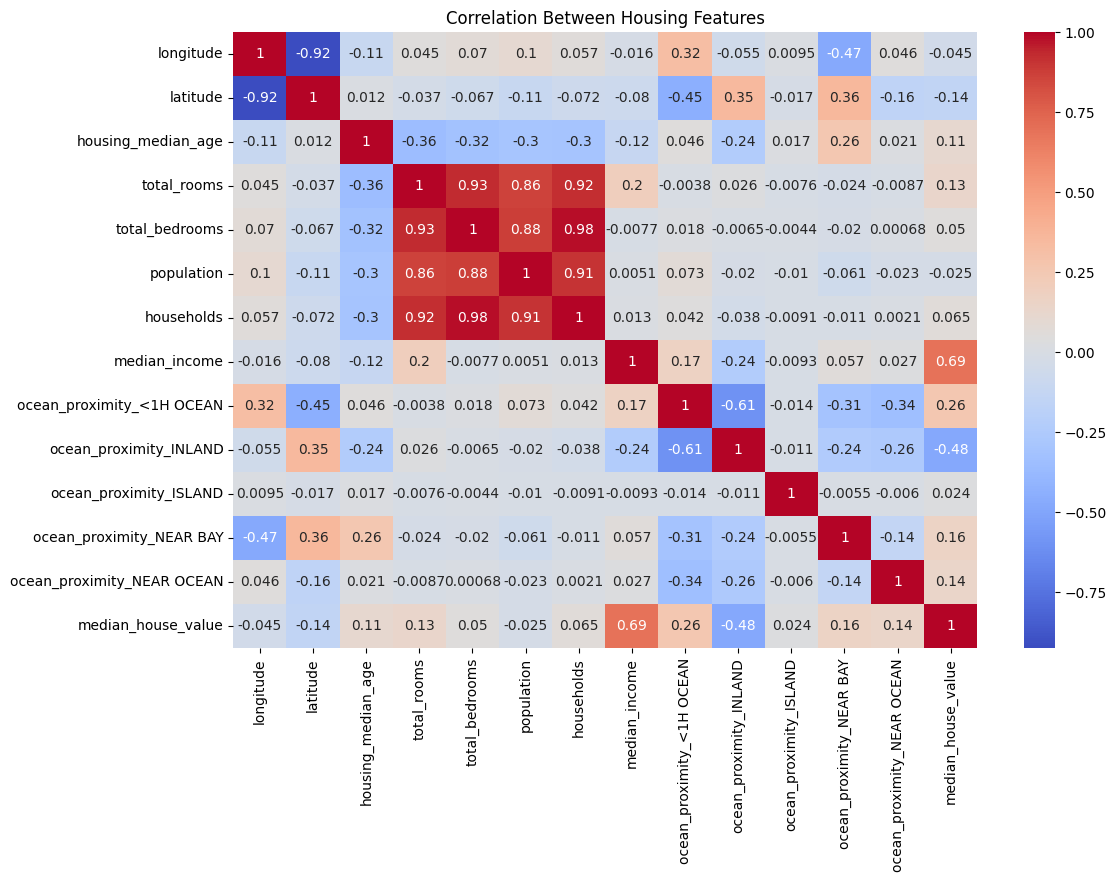

In [23]:
plt.figure(figsize=(12,8))

corr_matrix = data.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Between Housing Features")

plt.show()

## Task 15: Ocean Proximity vs House Price 

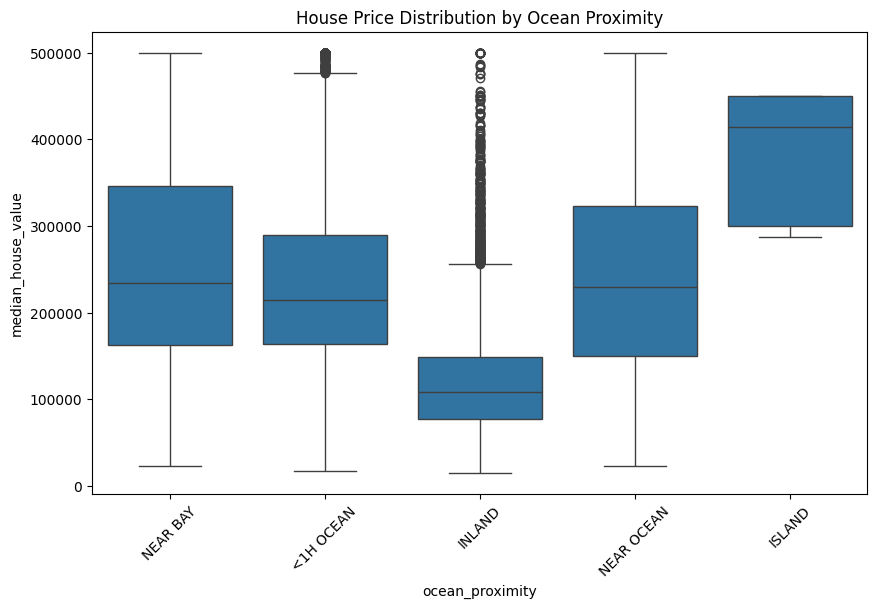

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(x='ocean_proximity', y='median_house_value', data=data)

plt.xticks(rotation=45)

plt.title("House Price Distribution by Ocean Proximity")

plt.show()

##  Task 17: Average House Price by Ocean Proximity

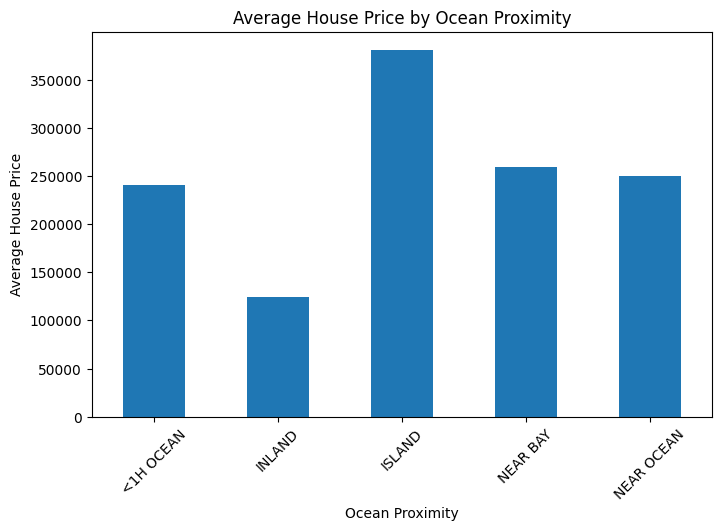

In [32]:
avg_price = pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv").groupby("ocean_proximity")["median_house_value"].mean()

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average House Price by Ocean Proximity")

plt.xlabel("Ocean Proximity")

plt.ylabel("Average House Price")

plt.xticks(rotation=45)

plt.show()

## Task 18 Geographic Distribution of House Prices

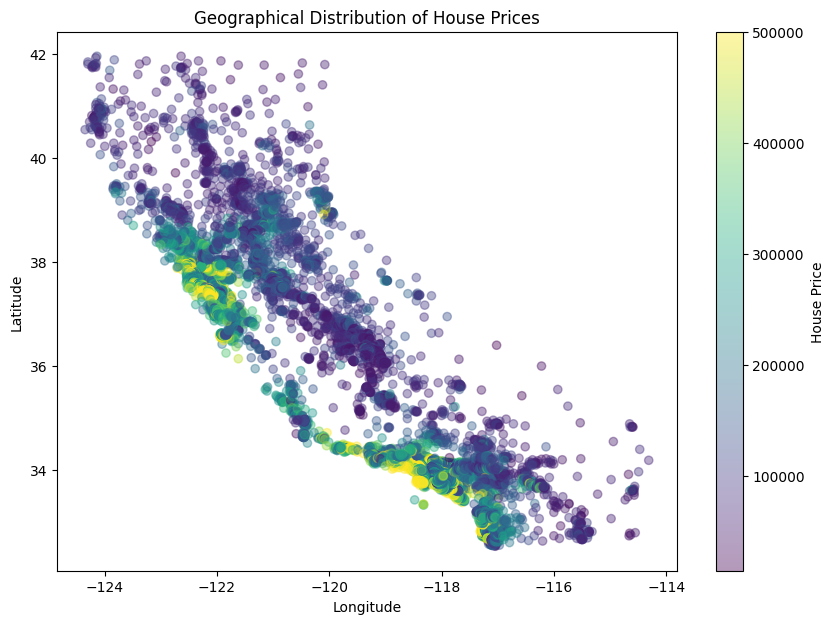

In [34]:
plt.figure(figsize=(10,7))

plt.scatter(
    pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv")["longitude"],
    pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv")["latitude"],
    c=pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv")["median_house_value"],
    cmap="viridis",
    alpha=0.4
)

plt.colorbar(label="House Price")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Geographical Distribution of House Prices")

plt.show()

## Task 19: Population vs House Price

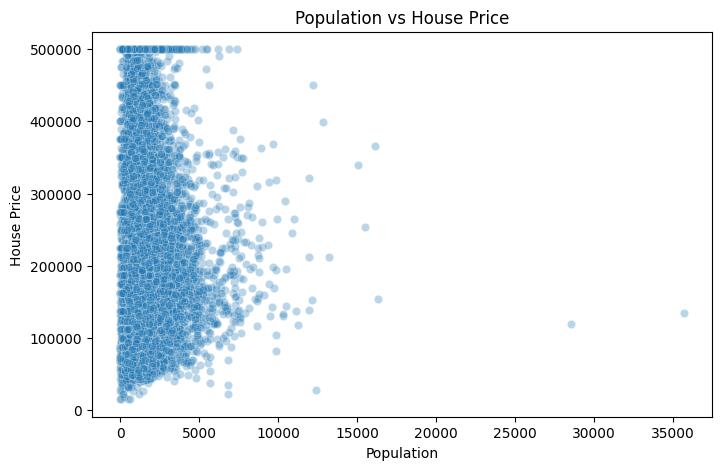

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='population',
    y='median_house_value',
    data=pd.read_csv("/Users/nithineleti/Downloads/PROJECTS/house_price_prediction_model/housing.csv"),
    alpha=0.3
)

plt.title("Population vs House Price")

plt.xlabel("Population")
plt.ylabel("House Price")

plt.show()

## Task 20: Model Performance Evaluation

In [36]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 4550878352.629268
Root Mean Squared Error: 67460.19828483509
R2 Score: 0.6572233688367524


## Task 21: Final Business Insights

Key Insights from the Housing Market Analysis

Median income is the strongest factor influencing house prices.

Houses located near the ocean tend to have higher property values.

Inland properties generally have lower prices compared to coastal areas.

Geographic location and income levels together play a major role in determining housing prices.

Population density has a weaker influence compared to economic indicators.

## Task 22: Final Conclusion

This project analyzed housing market data to understand the key factors influencing property prices. Through exploratory data analysis and regression modeling, we identified that median income and geographic location are the most significant predictors of house prices. The insights gained from this analysis can help support data-driven decision-making in real estate market analysis.